## Modeling

In [1]:
import gc
gc.collect()

35

In [2]:
# pip install imbalanced-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
pd.options.mode.chained_assignment = None

root = r"C:\Users\MHMD RAGAB\Downloads\DATA\New folder\\"

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_pickle(root + 'Finaldata.pkl')
df.head()

,user_id,product_id,times_bought,times_reordered,order_number,order_dow,order_hour_of_day,days_since_prior_order,reordered,total_orders_x,total_reorders,total_orders_y,unique_products
0,1,196,10.0,9.0,11.0,4.0,8.0,14.0,1.0,35791,27791,59,18
1,1,10258,9.0,8.0,11.0,4.0,8.0,14.0,1.0,1946,1389,59,18
2,1,10326,1.0,0.0,11.0,4.0,8.0,14.0,0.0,5526,3603,59,18
3,1,12427,10.0,9.0,11.0,4.0,8.0,14.0,0.0,6476,4797,59,18
4,1,13032,3.0,2.0,11.0,4.0,8.0,14.0,1.0,3751,2465,59,18


In [5]:
def reduce_memory(df):
    
    """
    This function reduce the dataframe memory usage by converting it's type for easier handling.
    
    Parameters: Dataframe
    Return: Dataframe
    """
    
    start_mem_usg = df.memory_usage().sum() / 1024**2 
    print("Memory usage of properties dataframe is :",start_mem_usg," MB")
    
    for col in df.columns:
        if df[col].dtypes in ["int64", "int32", "int16"]:
            
            cmin = df[col].min()
            cmax = df[col].max()
            
            if cmin > np.iinfo(np.int8).min and cmax < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            
            elif cmin > np.iinfo(np.int16).min and cmax < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            
            elif cmin > np.iinfo(np.int32).min and cmax < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        
        if df[col].dtypes in ["float64", "float32"]:
            
            cmin = df[col].min()
            cmax = df[col].max()
            
            if cmin > np.finfo(np.float16).min and cmax < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            
            elif cmin > np.finfo(np.float32).min and cmax < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    
    print("")
    print("___MEMORY USAGE AFTER COMPLETION:___")
    mem_usg = df.memory_usage().sum() / 1024**2 
    print("Memory usage is: ",mem_usg," MB")
    print("This is ",100*mem_usg/start_mem_usg,"% of the initial size")
    
    return df

In [6]:
df = reduce_memory(df)

Memory usage of properties dataframe is : 840.535041809082  MB

___MEMORY USAGE AFTER COMPLETION:___
Memory usage is:  274.79038429260254  MB
This is  32.69231746735647 % of the initial size


In [7]:
print(df.columns)

Index(['user_id', 'product_id', 'times_bought', 'times_reordered',
       'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'reordered', 'total_orders_x',
       'total_reorders', 'total_orders_y', 'unique_products'],
      dtype='object')


In [8]:
df['last_ordered_in'] = df.groupby(['user_id', 'product_id'])['order_number'].transform('max')

In [9]:
df['order_diff'] = df['order_number'] - df['last_ordered_in']

In [10]:

df.drop(['user_id', 'product_id'], axis = 1, inplace = True)

In [11]:
df.head()

,times_bought,times_reordered,order_number,order_dow,order_hour_of_day,days_since_prior_order,reordered,total_orders_x,total_reorders,total_orders_y,unique_products,last_ordered_in,order_diff
0,10.0,9.0,11.0,4.0,8.0,14.0,1.0,35791,27791,59,18,11.0,0.0
1,9.0,8.0,11.0,4.0,8.0,14.0,1.0,1946,1389,59,18,11.0,0.0
2,1.0,0.0,11.0,4.0,8.0,14.0,0.0,5526,3603,59,18,11.0,0.0
3,10.0,9.0,11.0,4.0,8.0,14.0,0.0,6476,4797,59,18,11.0,0.0
4,3.0,2.0,11.0,4.0,8.0,14.0,1.0,3751,2465,59,18,11.0,0.0


In [12]:
df.shape

(8474661, 13)

In [13]:
label = 'reordered'
x_cols = df.columns.drop('reordered')

In [14]:
X = df[x_cols]
y = df[label]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.25)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6355995, 12) (6355995,)
(2118666, 12) (2118666,)


In [16]:
y_train.value_counts()

reordered
0.0    5734377
1.0     621618
Name: count, dtype: int64

In [17]:
np.ceil(y_train.value_counts()[0]/y_train.value_counts()[1])

10.0

In [18]:
y_test.value_counts()

reordered
0.0    1911460
1.0     207206
Name: count, dtype: int64

In [19]:
# freeing memory
del df, X, y
gc.collect()

0

### Neural Network model

In [20]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l2
from keras.callbacks import History
from keras import backend as K
from sklearn.preprocessing import MinMaxScaler

In [21]:
sc = MinMaxScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [22]:
input_dim =  X_train_sc.shape[1]
input_dim

12

In [23]:
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [24]:
history = History()

classifier = Sequential()

classifier.add(Dense(units = 64, activation = 'relu', input_dim = input_dim))
classifier.add(Dense(units = 15, activation = 'relu'))
classifier.add(Dense(units = 4, activation = 'relu'))
classifier.add(Dense(units = 1, activation ='sigmoid'))

classifier.compile(optimizer = "adam", loss = 'binary_crossentropy', metrics = ['accuracy', f1_m, precision_m, recall_m])

classifier.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                832       
                                                                 
 dense_1 (Dense)             (None, 15)                975       
                                                                 
 dense_2 (Dense)             (None, 4)                 64        
                                                                 
 dense_3 (Dense)             (None, 1)                 5         
                                                                 
Total params: 1,876
Trainable params: 1,876
Non-trainable params: 0
_________________________________________________________________


In [27]:
gc.collect()

1404

In [28]:
%%time
# fit the model
classifier.fit(X_train_sc, y_train, epochs=5, batch_size=512, validation_split=0.15, verbose=1,class_weight= {0:1, 1:10},
          callbacks = [history, keras.callbacks.EarlyStopping(monitor='val_loss',
                                                              min_delta=0, patience=10, verbose=0, mode='auto')])

Epoch 1/5
10552/10552 [==============================] - 77s 7ms/step - loss: 1.0367 - accuracy: 0.7165 - f1_m: 0.3305 - precision_m: 0.2161 - recall_m: 0.7164 - val_loss: 0.6512 - val_accuracy: 0.6417 - val_f1_m: 0.3004 - val_precision_m: 0.1860 - val_recall_m: 0.7920
Epoch 2/5
10552/10552 [==============================] - 76s 7ms/step - loss: 1.0353 - accuracy: 0.7162 - f1_m: 0.3308 - precision_m: 0.2161 - recall_m: 0.7178 - val_loss: 0.5640 - val_accuracy: 0.7200 - val_f1_m: 0.3328 - val_precision_m: 0.2174 - val_recall_m: 0.7194
Epoch 3/5
10552/10552 [==============================] - 74s 7ms/step - loss: 1.0342 - accuracy: 0.7169 - f1_m: 0.3314 - precision_m: 0.2166 - recall_m: 0.7184 - val_loss: 0.5840 - val_accuracy: 0.7092 - val_f1_m: 0.3285 - val_precision_m: 0.2125 - val_recall_m: 0.7323
Epoch 4/5
10552/10552 [==============================] - 74s 7ms/step - loss: 1.0332 - accuracy: 0.7168 - f1_m: 0.3315 - precision_m: 0.2166 - recall_m: 0.7192 - val_loss: 0.5706 - val_accur

In [29]:
eval_model=classifier.evaluate(X_train_sc, y_train)
print('loss: ', eval_model[0], 'and Accuracy: ', eval_model[1])

198625/198625 [==============================] - 917s 5ms/step - loss: 0.5821 - accuracy: 0.7026 - f1_m: 0.3104 - precision_m: 0.2097 - recall_m: 0.7097
loss:  0.5821428298950195 and Accuracy:  0.7026492357254028


In [30]:
gc.collect()

2416

Text(0.5, 1.0, 'Loss')

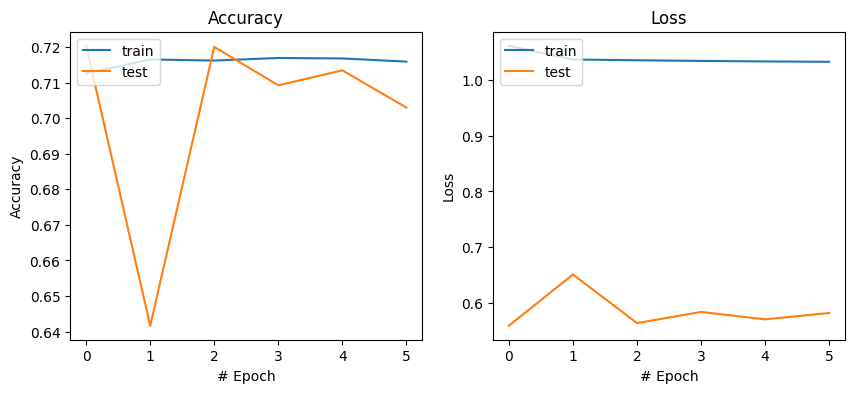

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Accuracy
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('# Epoch')
ax[0].legend(['train', 'test'], loc='upper left')
ax[0].set_title('Accuracy')

# Loss
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('# Epoch')
ax[1].legend(['train', 'test'], loc='upper left')
ax[1].set_title('Loss')

66209/66209 [==============================] - 114s 2ms/step

 Classification report : 
               precision    recall  f1-score   support

         0.0       0.96      0.70      0.81   1911460
         1.0       0.21      0.74      0.33    207206

    accuracy                           0.70   2118666
   macro avg       0.59      0.72      0.57   2118666
weighted avg       0.89      0.70      0.76   2118666

Accuracy Score :  0.7023627131411936
F1 Score:  0.3263489174048483
Area under curve :  0.7942386264957134 



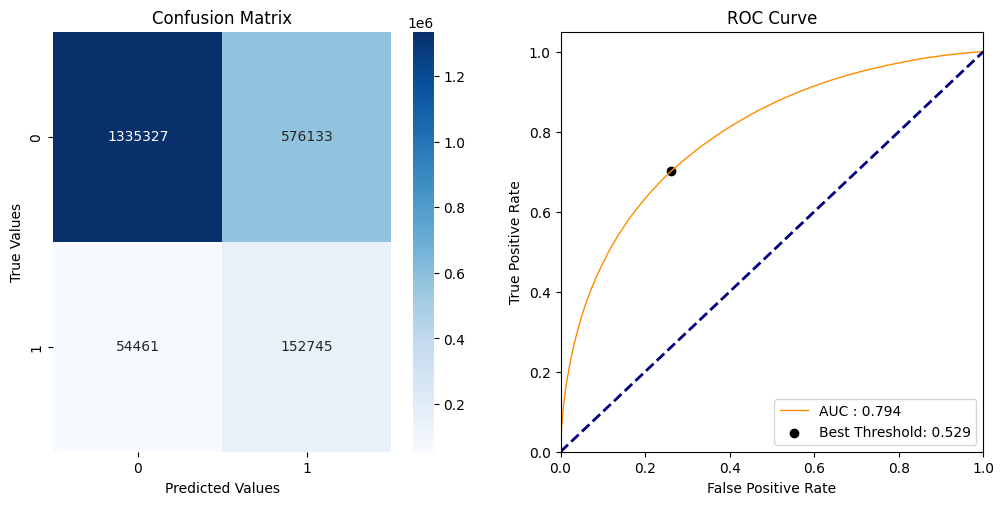

In [34]:
# probabilities
probabilities = classifier.predict(X_test_sc)

# predictions (binary classification)
predictions = (probabilities > 0.5).astype("int32")

# reshape (مهم عشان بعض الموديلات)
predictions = predictions.ravel()
probabilities = probabilities.ravel()

print("\n Classification report : \n", classification_report(y_test, predictions))
print("Accuracy Score : ", accuracy_score(y_test, predictions))

# confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(12, 12))
plt.subplot(221)

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues')

plt.title('Confusion Matrix')
plt.ylabel('True Values')
plt.xlabel('Predicted Values')

# f1-score
f1 = f1_score(y_test, predictions)
print("F1 Score: ", f1)

# roc-auc
model_roc_auc = roc_auc_score(y_test, probabilities)
print("Area under curve : ", model_roc_auc, "\n")

fpr, tpr, thresholds = roc_curve(y_test, probabilities)

gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
threshold = np.round(thresholds[ix], 3)

plt.subplot(222)
plt.plot(fpr, tpr, color='darkorange', lw=1, label="AUC : %.3f" % model_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.scatter(fpr[ix], tpr[ix], marker='o', color='black',
            label='Best Threshold: ' + str(threshold))

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()